In [1]:
# Chem 277B: Machine Learning Algorithms for
#            Molecular Sciences
#
# Date Created: 11/28/2024
# Last revisited: 11/29/2024


##################################
# FILE FOR RUNNING LSTM MODEL
##################################

'''can use lstm class to tune model parameters
and compare model output to actual data. Different metrics/graphs
and visualizations can be called from the utils file'''






'can use lstm class to tune model parameters\nand compare model output to actual data. Different metrics/graphs\nand visualizations can be called from the utils file'

In [2]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nrsim_lstm import NRSIM_LSTM as lstm
import utils277b as utils
from scope_2 import NuclearReactorSimulator

2024-12-02 21:28:01.237389: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# read data from csv file

#filepath="test_file"
#data = pd.read_csv(filepath)
simulation = NuclearReactorSimulator()
simulation.run_simulation()
data = pd.DataFrame(simulation.normalize_values())
data = data.drop("Time", axis=1)

data.head(5)

,pH,Hydrogen,Total Gas,Temperature,Pressure,Radioactivity,Power,Reactor Safety,Injection of Air,Resin Overheat,Fuel Element Failure,Chemical Addition,Vent Gas
0,0.929646,0.511828,0.511828,0.259772,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.927694,0.536852,0.536852,0.273368,0.526168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925743,0.561864,0.561864,0.286926,0.552264,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.923791,0.586794,0.586794,0.300410,0.578217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.921840,0.611574,0.611574,0.313782,0.603956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#n_past = int(data.shape[0] * 0.5)
#m_future = data.shape[0] - n_past
n_past = 200
m_future = 200 
display(n_past)
display(m_future)

200

200

In [5]:
data

,pH,Hydrogen,Total Gas,Temperature,Pressure,Radioactivity,Power,Reactor Safety,Injection of Air,Resin Overheat,Fuel Element Failure,Chemical Addition,Vent Gas
0,0.929646,0.511828,0.511828,0.259772,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.927694,0.536852,0.536852,0.273368,0.526168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925743,0.561864,0.561864,0.286926,0.552264,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.923791,0.586794,0.586794,0.300410,0.578217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.921840,0.611574,0.611574,0.313782,0.603956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4316,0.520460,0.367164,0.367164,0.205763,0.396044,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4317,0.518508,0.391456,0.391456,0.219135,0.421783,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4318,0.516557,0.416004,0.416004,0.232619,0.447736,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4319,0.514605,0.440744,0.440744,0.246177,0.473832,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
features = 13
X, y = utils.prep_lstm_data(np.array(data), n_past, m_future)

In [7]:
X = X.squeeze()
y = y.squeeze()
X = X[:, :, :7]
y = y[:, :, :7]

In [8]:
print(X.shape, y.shape)

(3922, 200, 7) (3922, 200, 7)


In [9]:
# # setting up training data

# n_past = 100
# m_future = 50
# features = 1

# target_param = "Injection of Air"

# # t represents time steps
# t = data["Time"].values
# t = t.reshape(len(t), 1)

# # y(t) is the value of the target parameter at time t
# y_t = data[target_param].values
# y_t = y_t.reshape(len(y_t), 1)

# scaler, y_t_normalized = utils.scale(y_t)

# # creating training and testing data
# X, y = utils.prep_lstm_data(y_t_normalized, n_past, m_future)

# split_point = int(0.8 * len(data))
# X = np.array(data.iloc[:split_point, :])
# Y = np.array(data.iloc[:split_point, :])


#plt.plot(range(0, y.shape[0]), y)
#plt.xlabel("Time")
#plt.ylabel(f"{target_param}")
#plt.title(f"Nuclear Reactor Simulation {target_param} vs Time")
#plt.show()

In [10]:
# each shape[1] value corresponds to the number of points in the past 
# and number of points in the future for X and y, respectively

print(X.shape, y.shape)

(3922, 200, 7) (3922, 200, 7)


In [11]:
# train test splitting data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

In [12]:
# model setup 

# stacked lstm layers
neurons = [12, 6]
activation = "tanh"

# temporal params
n_past_timesteps = X.shape[1]
n_features = X.shape[2]
n_predicted_timesteps = y.shape[1]

# optimization + metrics
optimizer = "adam"
loss = "mse"
metrics =["mae", "mse"]

# convolutional layer
conv_layer = False
nfilters = 64  
conv_act = 'relu' 
pool_size = 2  
dropout=0


my_model = lstm(
    neurons,
    activation,
    n_past_timesteps,
    n_features,
    n_predicted_timesteps,
    optimizer,
    loss,
    metrics,
    dropout,
    conv_layer,
    nfilters,
    conv_act,
    pool_size
)

2024-12-02 21:28:29.031602: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2024-12-02 21:28:29.483906: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 21:28:29.486031: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 21:28:29.4

In [14]:
my_model.model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 200, 12)           960       
                                                                 
 lstm_1 (LSTM)               (None, 200, 6)            456       
                                                                 
 dense (Dense)               (None, 200, 7)            49        
                                                                 
Total params: 1,465
Trainable params: 1,465
Non-trainable params: 0
_________________________________________________________________


In [15]:
# fitting model on training data

n_epochs = 20
batch_size = 32


my_model.fit(X_train, y_train, nEpochs=n_epochs, nBatches=batch_size, val_split=0.2, verb=2, shuf=False)


Epoch 1/20


2024-12-02 21:28:45.021938: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 21:28:45.025239: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 21:28:45.028063: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

74/74 - 44s - loss: 0.1211 - mae: 0.2686 - mse: 0.1211 - val_loss: 0.0809 - val_mae: 0.2300 - val_mse: 0.0809 - 44s/epoch - 595ms/step
Epoch 2/20
74/74 - 33s - loss: 0.0700 - mae: 0.2071 - mse: 0.0700 - val_loss: 0.0795 - val_mae: 0.2326 - val_mse: 0.0795 - 33s/epoch - 452ms/step
Epoch 3/20
74/74 - 35s - loss: 0.0644 - mae: 0.1984 - mse: 0.0644 - val_loss: 0.0792 - val_mae: 0.2321 - val_mse: 0.0792 - 35s/epoch - 469ms/step
Epoch 4/20
74/74 - 34s - loss: 0.0604 - mae: 0.1917 - mse: 0.0604 - val_loss: 0.0745 - val_mae: 0.2268 - val_mse: 0.0745 - 34s/epoch - 466ms/step
Epoch 5/20
74/74 - 36s - loss: 0.0554 - mae: 0.1829 - mse: 0.0554 - val_loss: 0.0682 - val_mae: 0.2105 - val_mse: 0.0682 - 36s/epoch - 491ms/step
Epoch 6/20
74/74 - 35s - loss: 0.0503 - mae: 0.1743 - mse: 0.0503 - val_loss: 0.0654 - val_mae: 0.2053 - val_mse: 0.0654 - 35s/epoch - 477ms/step
Epoch 7/20
74/74 - 34s - loss: 0.0457 - mae: 0.1631 - mse: 0.0457 - val_loss: 0.0582 - val_mae: 0.1882 - val_mse: 0.0582 - 34s/epoch - 

In [16]:
# model history

out = my_model.get_model().history

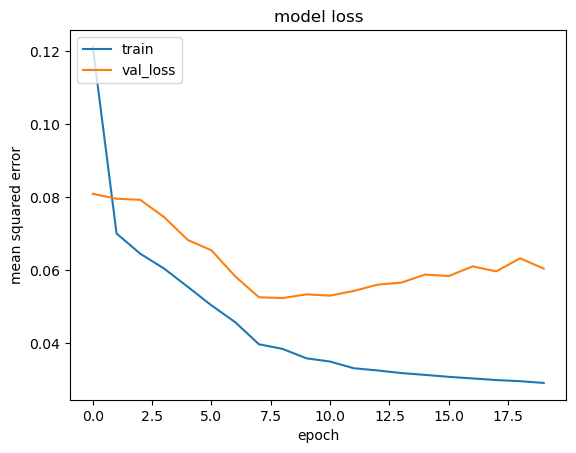

In [17]:
# plotting loss during training
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('mean squared error')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()


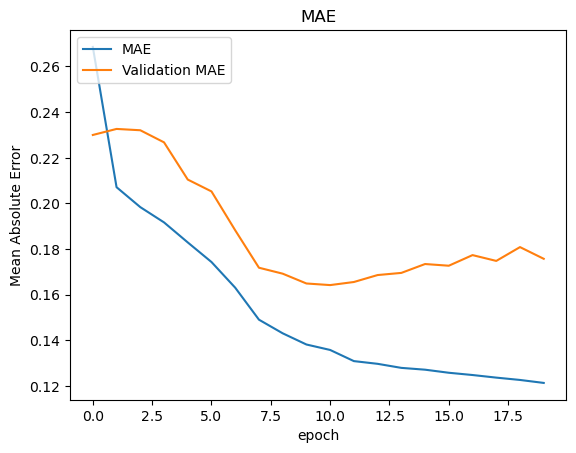

In [18]:
# plot metrics
plt.plot(out.history['mae'])
plt.plot(out.history['val_mae'])
plt.title('MAE')
plt.ylabel('Mean Absolute Error')
plt.xlabel('epoch')
plt.legend(['MAE', 'Validation MAE'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()

In [19]:
y_train.shape

(2941, 200, 7)

In [20]:
def graph_features(data, safety_features = ["Reactor Safety", "Injection of Air", "Resin Overheat", "Fuel Element Failure"]):
    colors = plt.rcParams["axes.prop_cycle"]()
    df = data
    fig, axs = plt.subplots(len(safety_features), figsize=(10,8))
    fig.suptitle('Simulated Reactor Safety Over Time')
    for i in range(len(safety_features)): 
        c = next(colors)["color"]
        x = safety_features[i]
        axs[i].plot(range(0, df.shape[0]), df[:,i], color = c)
        axs[i].set_title(x)
        axs[i].set_xlabel("Time (miliseconds)")
        
    plt.subplots_adjust(wspace=1, hspace=3)

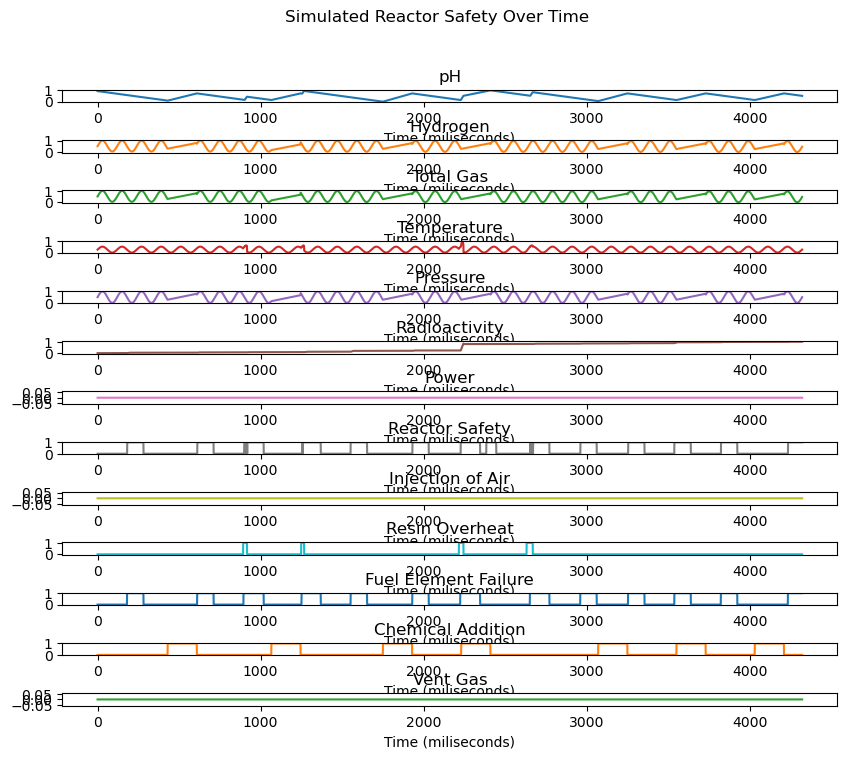

In [21]:
graph_features(np.array(data), safety_features = data.columns)

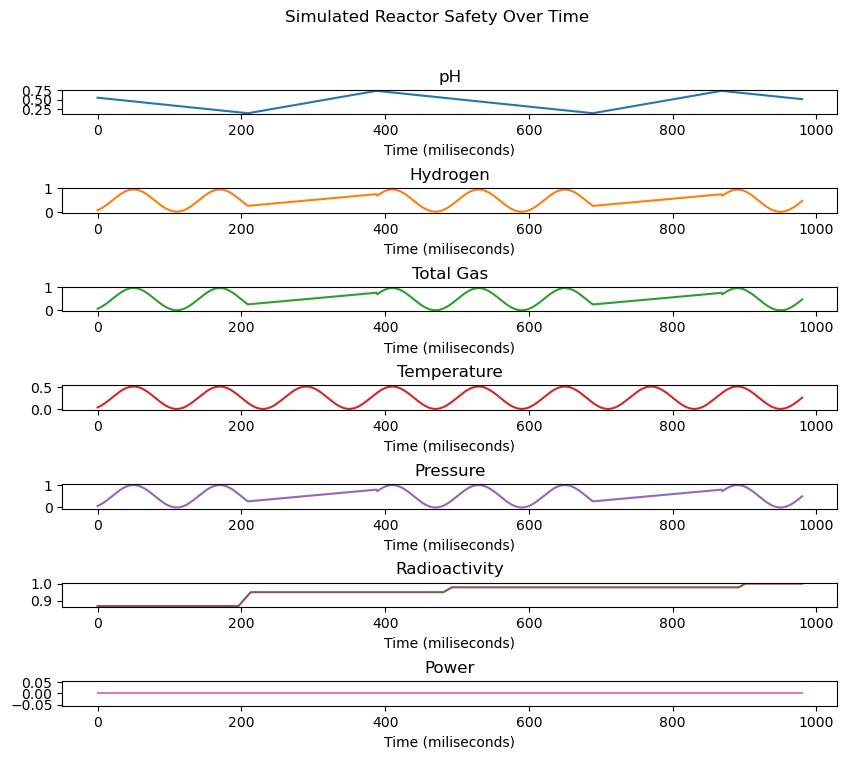

In [38]:
graph_features(y_test[:,199,:], safety_features=data.columns[:7])

In [23]:
y_pred_normalized = my_model.predict(X_test)

2024-12-02 21:41:11.858512: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 21:41:11.860776: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 21:41:11.862690: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

31/31 [==============================] - 4s 99ms/step


In [24]:
y_pred_normalized.shape

(981, 200, 7)

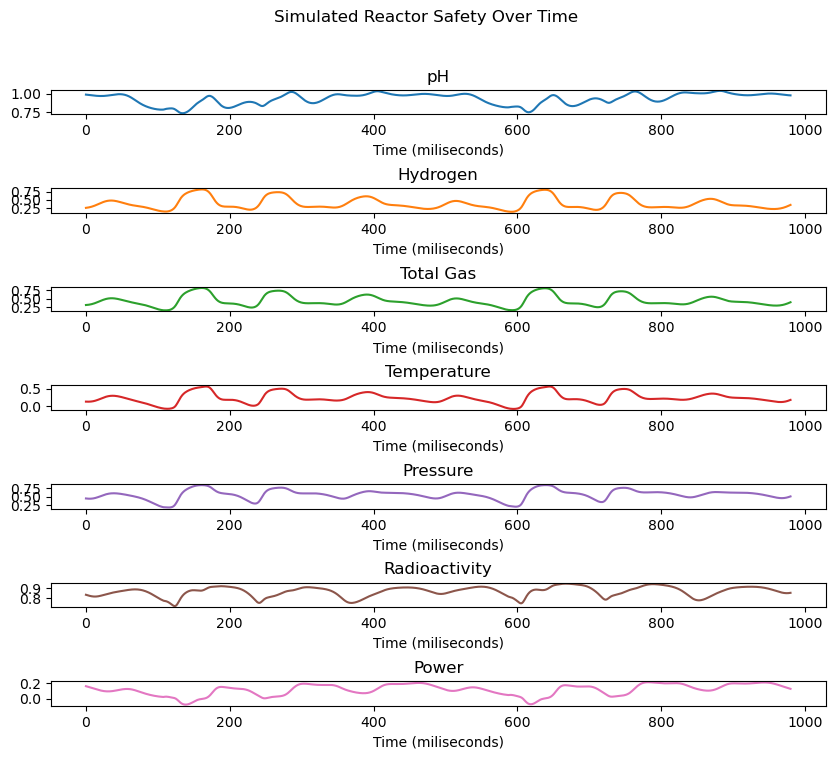

In [37]:
graph_features(y_pred_normalized[:, 199, :], safety_features = data.columns[:7])

In [27]:
print(y_train.shape, y_test.shape)

(2941, 200, 7) (981, 200, 7)


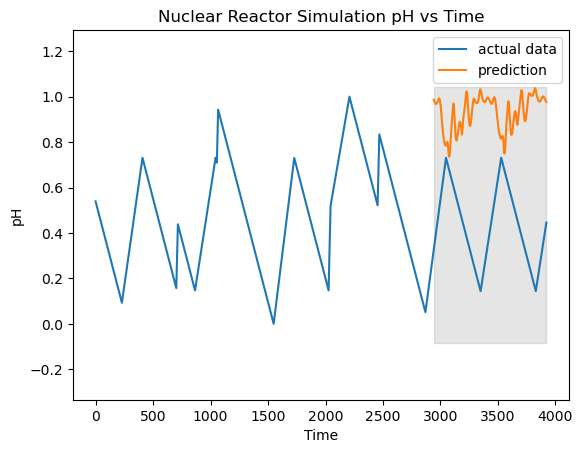

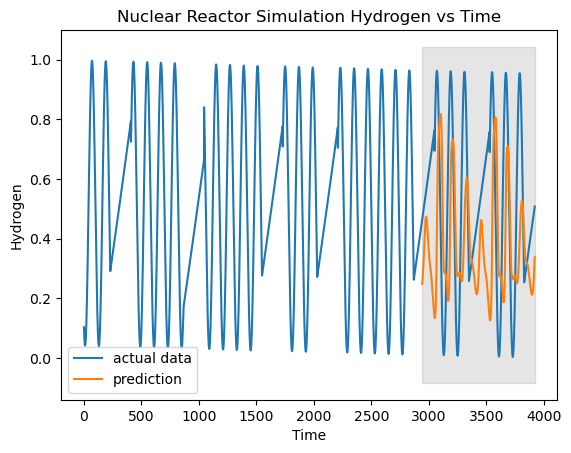

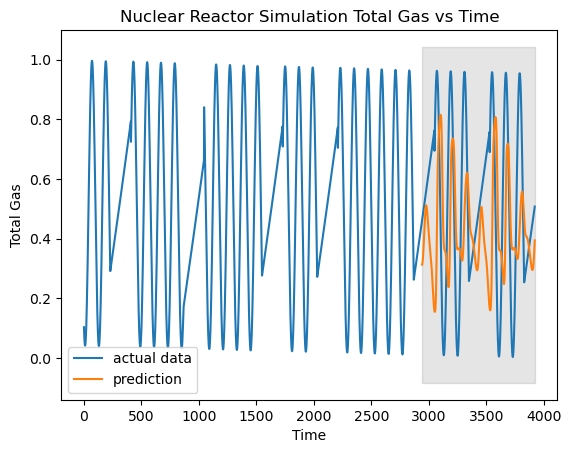

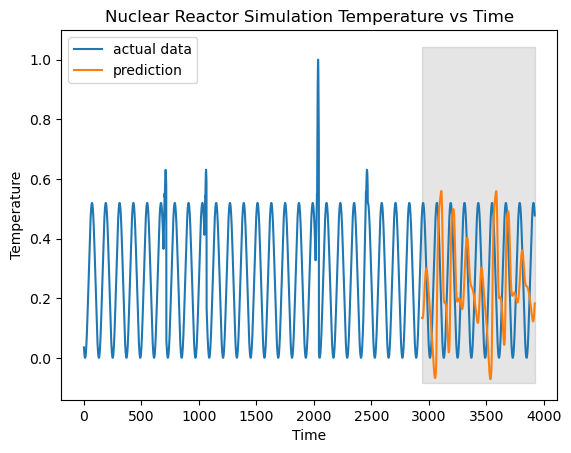

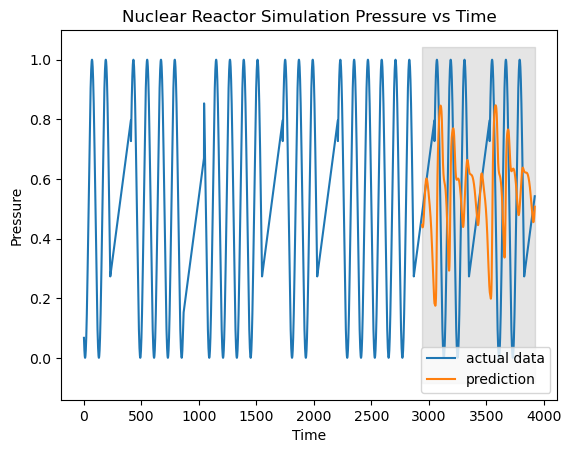

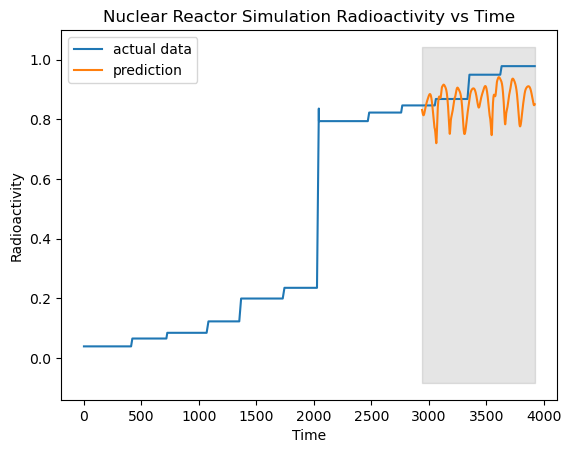

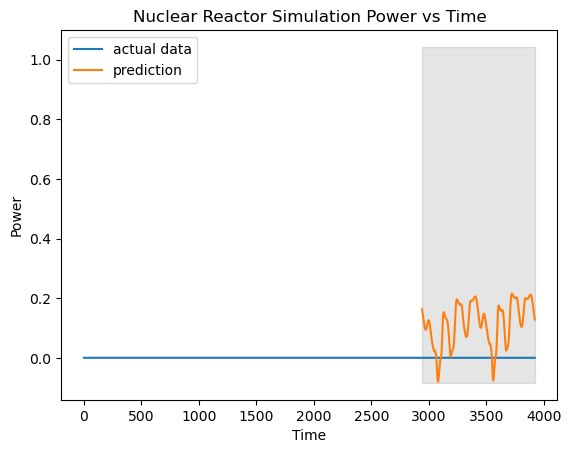

In [36]:
# predicting + transforming normalized data 
back  = y_pred_normalized.shape[0]
y_pred = y_pred_normalized
y_t = y[:, 0, :]
t = range(0,y.shape[0])
# setting bounds for graph
y_min = min(np.min(y_pred), np.min(y_t)) 
y_max = max(np.max(y_pred), np.max(y_t))
plt.ylim(y_min - 0.25, y_max + 0.25)

#parameter_i = 4
for parameter_i in range(7):
    # plot
    plt.plot(t, y_t[:, parameter_i])
    plt.plot(t[-back:], y_pred[:, m_future-1, parameter_i])
    plt.legend(['actual data', 'prediction'])
    plt.fill_between([y_train.shape[0], y_t.shape[0]], y_min, y_max , color = 'k', alpha = 0.1)
    #plt.plot([t[-back,0], t[-back,0]], [y_min, y_max ], 'k-')
    plt.xlabel("Time")
    plt.ylabel(f"{data.columns[parameter_i]}")
    plt.title(f"Nuclear Reactor Simulation {data.columns[parameter_i]} vs Time")
    plt.show()

In [40]:
y_pred.shape

(1043, 50)